In [ ]:
!pip install -e /scratch/synced 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from psi_net.cartesian import CartesianCoordinates, CartesianInitialCondition, CartesianSchrodinger

/opt/coiled/env/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
a = 1.0

time = torch.linspace(0, 1, 100)
space = torch.linspace(0, a, 100)

potential = lambda t, x: torch.zeros_like(x)

hbar = 1.0
m = 1.0

In [3]:
# --- Step 1A: exact infinite-well physics ---
# We write the exact eigenstates once, so every later comparison is against
# the analytic solution, not just against the training loss.

import numpy as np
import matplotlib.pyplot as plt
import torch

def phi_n(x, n, a=1.0):
  """
  Spatial eigenfunction for the infinite square well on [0, a].

  Physics:
  - n controls the number of half-wavelengths in the box.
  - n=1 is the ground state.
  - n=2 is the first excited state.
  """
  x = torch.as_tensor(x, dtype=torch.float32)
  return np.sqrt(2.0 / a) * torch.sin(n * torch.pi * x / a)

def energy_n(n, hbar=1.0, m=1.0, a=1.0):
  """
  Exact energy eigenvalue.

  Physics:
  - Higher n means higher curvature in space.
  - Higher curvature means larger kinetic energy.
  """
  return (n**2) * (np.pi**2) * (hbar**2) / (2.0 * m * a**2)

def exact_eigenstate_parts(t, x, n, a=1.0, hbar=1.0, m=1.0):
  """
  Exact real and imaginary parts of psi_n(x, t).

  Physics:
  - The spatial shape is fixed: phi_n(x)
  - Time only contributes a global phase exp(-i E_n t / hbar)
  - Therefore |psi|^2 is time-independent for a pure eigenstate
  """
  t = torch.as_tensor(t, dtype=torch.float32)
  x = torch.as_tensor(x, dtype=torch.float32)

  phi = phi_n(x, n=n, a=a)
  omega = energy_n(n=n, hbar=hbar, m=m, a=a) / hbar

  psi_R = phi * torch.cos(omega * t)
  psi_I = -phi * torch.sin(omega * t)
  return psi_R, psi_I

def make_eigenstate_initial_conditions(n, a=1.0):
  """
  Build the PINN boundary and initial conditions for a pure eigenstate.

  Physics:
  - At t=0 we impose psi(x,0) = phi_n(x)
  - At x=0 and x=a we impose the infinite-well walls: psi = 0
  """
  return [
      CartesianInitialCondition(
          CartesianCoordinates.T,
          0.0,
          psi_R=lambda time, space: phi_n(space, n=n, a=a),
          psi_I=lambda time, space: torch.zeros_like(space),
      ),
      CartesianInitialCondition(
          CartesianCoordinates.X,
          0.0,
          psi_R=lambda time, space: torch.zeros_like(space),
          psi_I=lambda time, space: torch.zeros_like(space),
      ),
      CartesianInitialCondition(
          CartesianCoordinates.X,
          a,
          psi_R=lambda time, space: torch.zeros_like(space),
          psi_I=lambda time, space: torch.zeros_like(space),
      ),
  ]

In [4]:
torch.manual_seed(1)
np.random.seed(1)

def phi_n_torch(x, n, a=1.0):
  return np.sqrt(2.0 / a) * torch.sin(n * torch.pi * x / a)

def omega_n(n, hbar=1.0, m=1.0, a=1.0):
  return energy_n(n=n, hbar=hbar, m=m, a=a) / hbar

def psi_super_exact_parts(t, x):
  phi1 = phi_n_torch(x, 1, a)
  phi2 = phi_n_torch(x, 2, a)
  w1 = omega_n(1, hbar=hbar, m=m, a=a)
  w2 = omega_n(2, hbar=hbar, m=m, a=a)
  psi_r = (phi1 * torch.cos(w1 * t) + phi2 * torch.cos(w2 * t)) / np.sqrt(2.0)
  psi_i = -(phi1 * torch.sin(w1 * t) + phi2 * torch.sin(w2 * t)) / np.sqrt(2.0)
  return psi_r, psi_i

def make_superposition_conditions():
  def psi_r_t0(t, x):
      return (phi_n_torch(x, 1, a) + phi_n_torch(x, 2, a)) / np.sqrt(2.0)

  def psi_i_t0(t, x):
      return torch.zeros_like(x)

  def dpsi_r_dt_t0(t, x):
      return torch.zeros_like(x)

  def dpsi_i_dt_t0(t, x):
      return -(
          omega_n(1, hbar=hbar, m=m, a=a) * phi_n_torch(x, 1, a)
          + omega_n(2, hbar=hbar, m=m, a=a) * phi_n_torch(x, 2, a)
      ) / np.sqrt(2.0)

  conditions = [
      CartesianInitialCondition(
          CartesianCoordinates.T,
          0.0,
          psi_R=psi_r_t0,
          psi_I=psi_i_t0,
          weight=2.0,
      ),
      CartesianInitialCondition(
          CartesianCoordinates.T,
          0.0,
          psi_R=dpsi_r_dt_t0,
          psi_I=dpsi_i_dt_t0,
          derivative=True,
          weight=2.0,
      ),
      CartesianInitialCondition(
          CartesianCoordinates.X,
          0.0,
          psi_R=lambda t, x: torch.zeros_like(x),
          psi_I=lambda t, x: torch.zeros_like(x),
          weight=1.0,
      ),
      CartesianInitialCondition(
          CartesianCoordinates.X,
          a,
          psi_R=lambda t, x: torch.zeros_like(x),
          psi_I=lambda t, x: torch.zeros_like(x),
          weight=1.0,
      ),
  ]

  return conditions

# --- Time-slice anchors: exact solution sampled densely across the beat period ---
# TODO: remove this once we start integrating conservation law losses
anchor_times = np.arange(0.05, 1.0, 0.05).tolist()  # 19 anchors
anchors = [
  CartesianInitialCondition(
      CartesianCoordinates.T,
      t_anchor,
      psi_R=lambda t, x, _t=t_anchor: psi_super_exact_parts(
          torch.full_like(x, _t), x
      )[0],
      psi_I=lambda t, x, _t=t_anchor: psi_super_exact_parts(
          torch.full_like(x, _t), x
      )[1],
      weight=1.0,
  )
  for t_anchor in anchor_times
]

plt.close("all")

torch.manual_seed(1)
np.random.seed(1)

solver_super = CartesianSchrodinger(
  coordinates=[time, space],
  V=potential,
  initial_conditions=make_superposition_conditions(),
  hbar=hbar,
  m=m,
  hidden_size=128,
  num_layers=4,
)

history_super = solver_super.train(
  num_epochs=10000,
  learning_rate=2e-4,
  phase1_learning_rate=2e-4,
  phase2_learning_rate=5e-5,
  de_weight=1e-8,
  print_every=1000,
  frac_epochs_ic_only=0.3,
  phase1_ic_weight=1.0,
  phase1_norm_weight=1.0,
  phase2_ic_weight=10.0,
  phase2_norm_weight=10.0,
  anchors=anchors,
  anchor_weight=10.0,
  noise_std=0.0,
)

Phase 1 Epoch 0: IC=203.834412, Norm=0.990489 (raw=0.990489), Mass(mean/min/max)=0.004767/0.003185/0.006248, Total=204.824905
Phase 1 Epoch 1000: IC=0.017751, Norm=0.000952 (raw=0.000952), Mass(mean/min/max)=0.999503/0.866243/1.049530, Total=0.018703
Phase 1 Epoch 2000: IC=163.088745, Norm=0.804124 (raw=0.804124), Mass(mean/min/max)=0.103270/0.102541/0.104116, Total=163.892868
Phase 1 restore best checkpoint from epoch 1356: Total=0.003614
Phase 2 Epoch 0: IC=0.034101, DE=0.000000 (raw=45178.011719), Anchor=204.667572 (raw=20.466757), Norm=0.002039 (raw=0.000204), Mass(mean/min/max)=0.998116/0.934856/1.036049, Total=204.703705
Phase 2 Epoch 1000: IC=1.033074, DE=0.000126 (raw=44125.210938), Anchor=67.536003 (raw=6.753600), Norm=7.100656 (raw=0.710066), Mass(mean/min/max)=0.168347/0.080421/0.767825, Total=75.669861
Phase 2 Epoch 2000: IC=0.619703, DE=0.000452 (raw=79119.820312), Anchor=27.779442 (raw=2.777944), Norm=2.906000 (raw=0.290600), Mass(mean/min/max)=0.486437/0.210828/0.941572,

In [5]:
def compute_mode_coefficients(psi_R, psi_I, x_vals, modes=(1, 2), a=1.0):
  psi_complex = psi_R + 1j * psi_I
  coeffs = {}

  for n in modes:
      phi = np.sqrt(2.0 / a) * np.sin(n * np.pi * x_vals / a)
      coeffs[n] = np.trapezoid(phi[None, :] * psi_complex, x=x_vals, axis=1)

  return coeffs

Initial modal weights:
n=1: |c_1(0)|^2 = 0.499452
n=2: |c_2(0)|^2 = 0.499711
Mean modal weights over time:
n=1: mean |c_1(t)|^2 = 0.474400
n=2: mean |c_2(t)|^2 = 0.481944


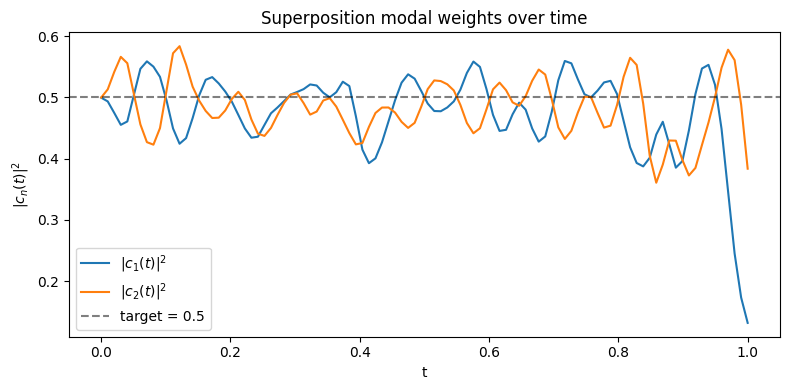

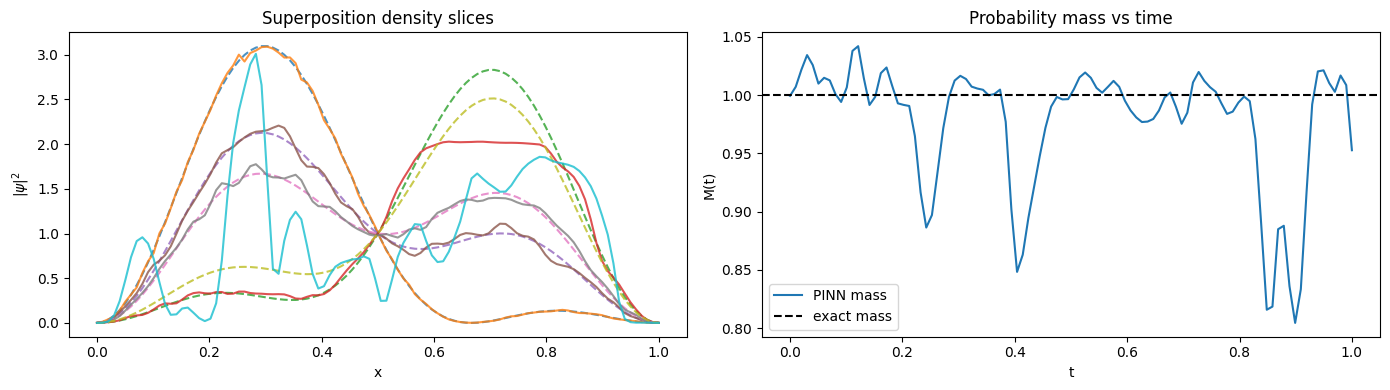

In [6]:
# --- Superposition modal-weight analysis and plot ---

solution_super = solver_super.get_solution()
t_vals = np.sort(solution_super["t"].unique())
x_vals = np.sort(solution_super["x"].unique())

nt = len(t_vals)
nx = len(x_vals)

psi_R_nn = solution_super["psi_R"].to_numpy().reshape(nt, nx)
psi_I_nn = solution_super["psi_I"].to_numpy().reshape(nt, nx)

coeffs = compute_mode_coefficients(
  psi_R_nn,
  psi_I_nn,
  x_vals,
  modes=(1, 2),
  a=a,
)

print("Initial modal weights:")
for n, c_n in coeffs.items():
  print(f"n={n}: |c_{n}(0)|^2 = {np.abs(c_n[0])**2:.6f}")

print("Mean modal weights over time:")
for n, c_n in coeffs.items():
  print(f"n={n}: mean |c_{n}(t)|^2 = {np.mean(np.abs(c_n)**2):.6f}")

plt.figure(figsize=(8, 4))
plt.plot(t_vals, np.abs(coeffs[1])**2, label=r"$|c_1(t)|^2$")
plt.plot(t_vals, np.abs(coeffs[2])**2, label=r"$|c_2(t)|^2$")
plt.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="target = 0.5")
plt.xlabel("t")
plt.ylabel(r"$|c_n(t)|^2$")
plt.title("Superposition modal weights over time")
plt.legend()
plt.tight_layout()
plt.show()


# --- Superposition density and mass plots ---

def psi_r_super_theoretical(t, x):
  return (1 / np.sqrt(2)) * sum(
      np.sqrt(2 / a) * np.sin(n * np.pi * x / a) *
      np.cos(n**2 * np.pi**2 * hbar * t / (2 * m * a**2))
      for n in [1, 2]
  )

def psi_i_super_theoretical(t, x):
  return (1 / np.sqrt(2)) * sum(
      -np.sqrt(2 / a) * np.sin(n * np.pi * x / a) *
      np.sin(n**2 * np.pi**2 * hbar * t / (2 * m * a**2))
      for n in [1, 2]
  )

prob_nn = solution_super["probability_density"].to_numpy().reshape(nt, nx)

T, X = np.meshgrid(t_vals, x_vals, indexing="ij")
prob_theoretical = psi_r_super_theoretical(T, X)**2 + psi_i_super_theoretical(T, X)**2

mass_t = np.trapezoid(prob_nn, x=x_vals, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for t_pick in [0.0, 0.25, 0.50, 0.75, 1.0]:
  idx = np.argmin(np.abs(t_vals - t_pick))
  axes[0].plot(x_vals, prob_theoretical[idx], "--", alpha=0.8, label=f"exact t={t_vals[idx]:.2f}")
  axes[0].plot(x_vals, prob_nn[idx], alpha=0.8, label=f"PINN t={t_vals[idx]:.2f}")
axes[0].set_title("Superposition density slices")
axes[0].set_xlabel("x")
axes[0].set_ylabel(r"$|\psi|^2$")

axes[1].plot(t_vals, mass_t, label="PINN mass")
axes[1].axhline(1.0, color="k", linestyle="--", label="exact mass")
axes[1].set_title("Probability mass vs time")
axes[1].set_xlabel("t")
axes[1].set_ylabel("M(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

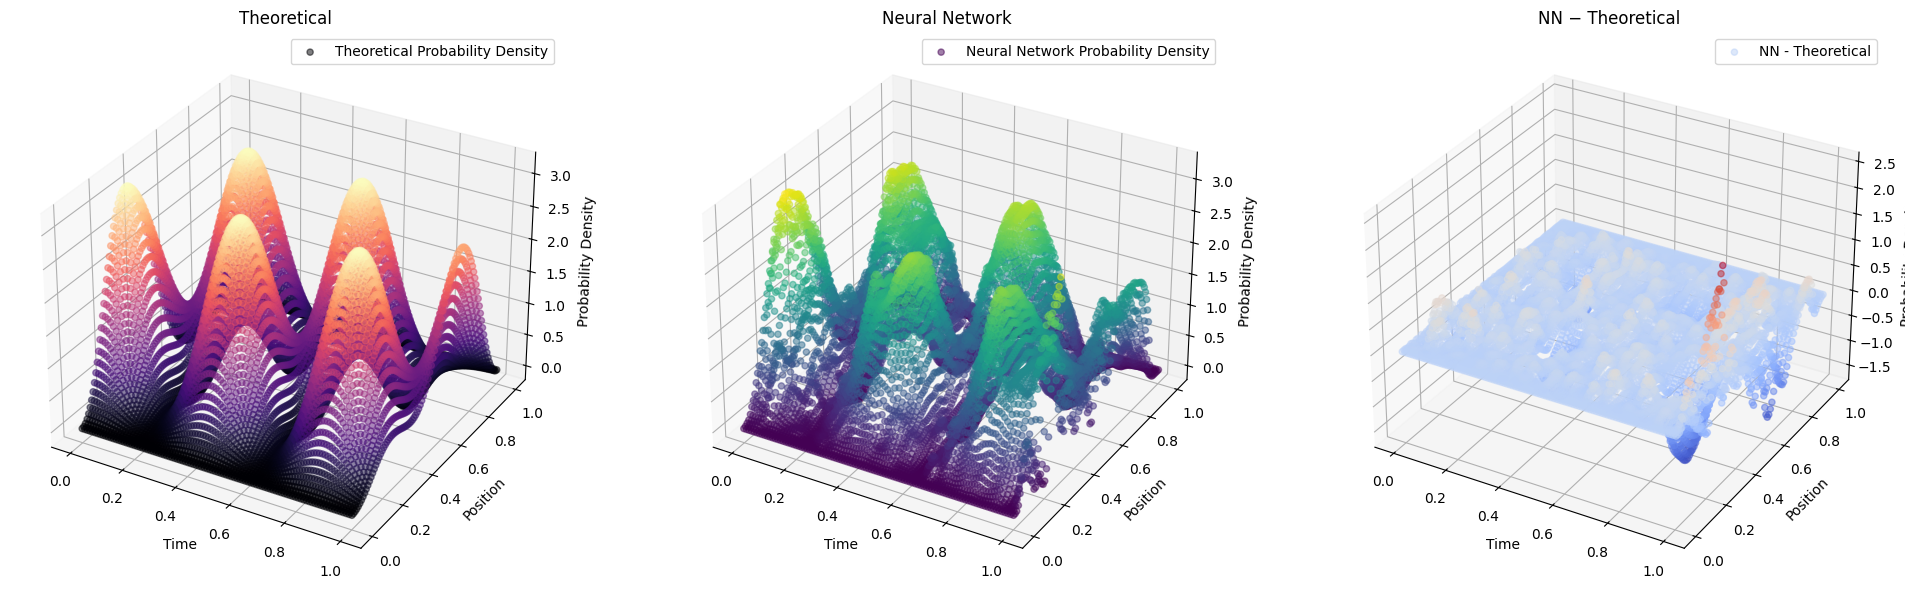

In [8]:
t_flat = T.ravel()                                                                                                                                                                                    
x_flat = X.ravel()                                                                                                                                                                                    
prob_theo_flat = prob_theoretical.ravel()                                                                                                                                                             
prob_nn_flat = prob_nn.ravel()                                                                                                                                                                        
diff_flat = prob_nn_flat - prob_theo_flat

fig = plt.figure(figsize=(20, 6))

ax = fig.add_subplot(131, projection='3d')
ax.scatter(t_flat, x_flat, prob_theo_flat, c=prob_theo_flat, cmap='magma', label='Theoretical Probability Density', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_zlabel('Probability Density')
plt.legend()
ax.set_title("Theoretical")

ax = fig.add_subplot(132, projection='3d')
ax.scatter(t_flat, x_flat, prob_nn_flat, c=prob_nn_flat, cmap='viridis', label='Neural Network Probability Density', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_zlabel('Probability Density')
plt.legend()
ax.set_title("Neural Network")

ax = fig.add_subplot(133, projection='3d')
ax.scatter(t_flat, x_flat, diff_flat, c=diff_flat, cmap='coolwarm', label='NN - Theoretical', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_zlabel('Probability Density')
plt.legend()
ax.set_title("NN − Theoretical")

plt.tight_layout()
plt.show()